# Exploratory Data Analysis (EDA)

## 1.Introduction

### Objective

The objective of this notebook is to explore customer behavior, identify important patterns related to churn, and generate business insights that can support customer retention strategies.

## Table of Contents

1. Introduction
2. Import Libraries
3. Load & Prepare Dataset
4. Churn Distribution Analysis
5. Contract Type Analysis
6. Tenure Analysis
7. Monthly Charges Analysis
8. Internet Service Analysis
9. Payment Method Analysis
10. Senior Citizen Analysis
11. Correlation Analysis
12. Key Business Insights
13. EDA Summary

## 2. Import Libraries

The required Python libraries are imported to perform data manipulation, visualization, and exploratory data analysis throughout this notebook.

In [8]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

## 3. Load & Prepare Dataset

The cleaned customer churn dataset is loaded and prepared for analysis. Basic preprocessing steps are performed to ensure that the data is suitable for visualization and business analysis.

In [9]:
df = pd.read_csv("../data/raw/Telco-Customer-Churn.csv")

In [10]:
# Replace blank spaces with NaN
df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)

# Convert to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])

# Remove rows with missing TotalCharges
df.dropna(inplace=True)

# Reset index
df.reset_index(drop=True, inplace=True)

## 4. Churn Distribution Analysis

### Objective

Analyze the overall distribution of customer churn to understand the proportion of customers who stayed versus those who left the company.

### 4.1 Customer Churn Distribution

This visualization illustrates the number of customers who churned compared to those who remained with the company.

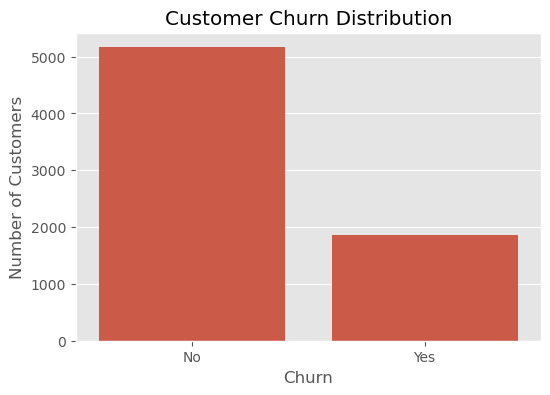

In [11]:
plt.figure(figsize=(6,4))

sns.countplot(x="Churn", data=df)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

## 📊 Observation

Approximately 26.5% of customers have churned, while nearly 73.5% have remained with the company. Although the majority of customers are retained, the proportion of churned customers is still significant enough to impact business performance.

---

## 💼 Business Insight

The dataset is moderately imbalanced, indicating that customer churn is a relatively less frequent event but remains an important business problem. Predicting potential churners can help the company reduce customer loss and improve long-term revenue.

---

## 🎯 Business Recommendation

Develop proactive retention strategies focused on customers who are at risk of churning. Personalized engagement, loyalty programs, and targeted promotional offers can help improve customer retention.

---

## 🤖 RetainAI Application

RetainAI will use customer information to identify individuals with a high probability of churn, enabling businesses to take preventive actions before customers decide to leave.

## 5. Contract Type Analysis

### Objective

Analyze the relationship between customer contract type and churn to determine whether contract duration influences customer retention.

### 5.1 Customer Distribution by Contract Type

This visualization displays the distribution of customers across different contract types to understand the company's customer base.

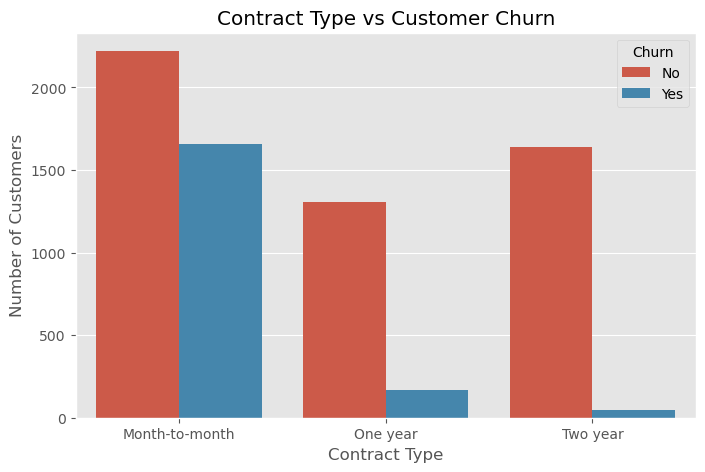

In [12]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Contract",
    hue="Churn",
    data=df
)

plt.title("Contract Type vs Customer Churn")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.show()

### Observation

Customers with month-to-month contracts have the highest churn, whereas customers with one-year and especially two-year contracts have much lower churn.

### Business Insight

Long-term contracts appear to improve customer retention because they increase customer commitment and reduce the likelihood of switching to competitors.

### Recommendation

The telecom company should focus retention campaigns on customers with month-to-month contracts. Offering discounts, loyalty rewards, or contract upgrade incentives may encourage them to move to longer-term plans.

### RetainAI Application

Contract type will be treated as an important predictive feature. If a customer has a month-to-month contract, the recommendation engine can suggest personalized retention offers before the customer decides to leave.

### 5.2 Churn Rate by Contract Type (%)

This visualization compares the percentage of customers who churned across different contract types, allowing a fair comparison irrespective of the number of customers in each category.

In [13]:
churn_rate = (
    df.groupby("Contract")["Churn"]
      .value_counts(normalize=True)
      .rename("Percentage")
      .mul(100)
      .reset_index()
)

churn_rate

,Contract,Churn,Percentage
0,Month-to-month,No,57.290323
1,Month-to-month,Yes,42.709677
2,One year,No,88.722826
3,One year,Yes,11.277174
4,Two year,No,97.151335
5,Two year,Yes,2.848665


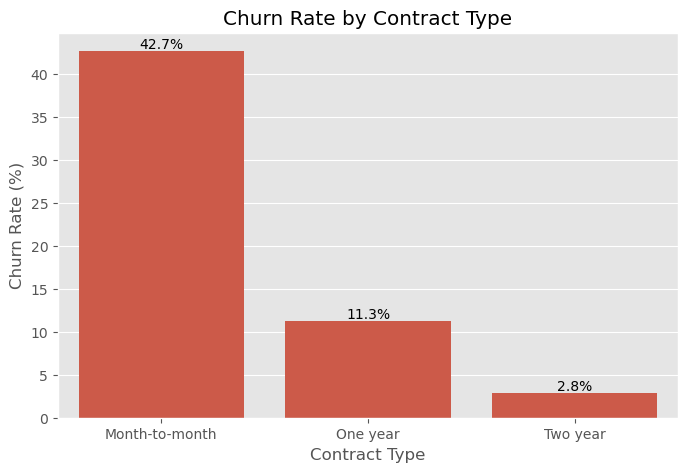

In [14]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=churn_rate[churn_rate["Churn"] == "Yes"],
    x="Contract",
    y="Percentage"
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.show()

### 📊 Observation

The churn rate is highest among customers with **month-to-month contracts** (approximately **43%**), followed by **one-year contracts** (approximately **11%**). Customers with **two-year contracts** have the lowest churn rate (approximately **3%**). This indicates a strong relationship between contract duration and customer retention.

---

### 💼 Business Insight

Customers with long-term contracts are significantly less likely to leave the company compared to customers with month-to-month contracts. This suggests that longer contract commitments improve customer loyalty and reduce the likelihood of switching to competitors.

---

### 🎯 Business Recommendation

The company should prioritize retention strategies for customers with month-to-month contracts. Personalized discounts, loyalty rewards, and attractive one-year or two-year contract offers can encourage customers to commit for a longer duration, ultimately reducing churn.

---

### 🤖 RetainAI Application

Contract type will be treated as a high-impact feature in the churn prediction model. If RetainAI identifies a customer with a **month-to-month contract** and a **high churn probability**, it can recommend personalized retention strategies such as contract upgrade offers, loyalty incentives, or promotional discounts before the customer decides to leave.

## 6. Tenure Analysis

### Objective

Analyze the relationship between customer tenure and churn to understand whether the duration of a customer's association with the company influences their likelihood of leaving.

### 6.1 Distribution of Customer Tenure

This visualization shows how long customers typically remain with the company. Understanding the distribution of customer tenure helps identify whether the customer base consists primarily of new customers, long-term customers, or a balanced mix of both.

#### Visualization 1

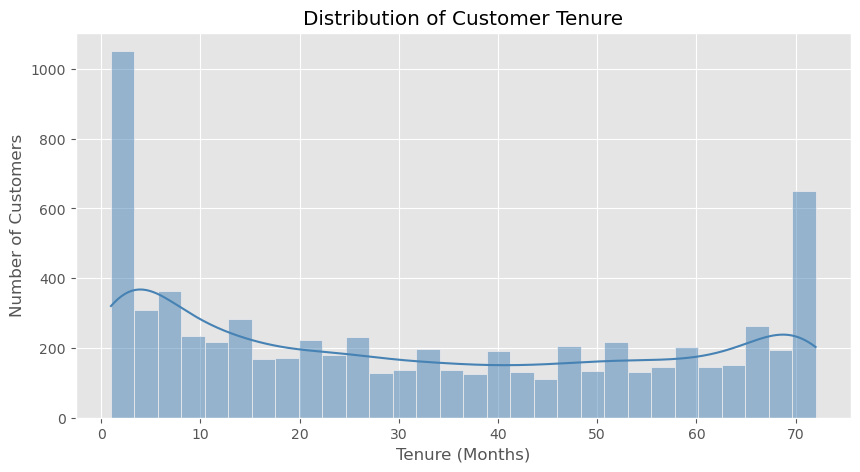

In [15]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="tenure",
    bins=30,
    kde=True,
    color="steelblue"
)

plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.show()

#### Visualization 2